# AG3 - Actividad Guiada 3
Nombre: Raul Contreras Oberto <br>
Link:   https://colab.research.google.com/drive/xxxxxxxxxxxxxxxxxxxxxxxxx <br>
Github: https://github.com/xxxxx/AlgoritmosOptimizacion
<br>

**Problema:** AG3 - Actividad Guiada 3

> 1. Desarrollar algoritmos con la técnica de búsqueda aleatoria
> 2. Desarrollar algoritmos con la técnica de búsqueda local
> 3. Desarrollar algoritmos con la técnica de recocido simulado(simulated annealing)

---



**Ruta:** master-universitario-en-ia-trb-miar042026/50688_algoritmos_de_optimizacion
/AG3_actividad_Guiada_3/
```           
📁 master-universitario-en-ia-trb-miar042026
   └── 📁 50688_Algoritmos_de_Optimizacion
       └── 📁 AG3_Actividad_Guiada_3
           ├── 📁 data
           │   └── 📄 swiss42.tsp
           ├── 📄 01_Raul_Contreras_Algoritmos_AG3_revisado.ipynb     
           └── 📄 README.md
```


#Carga de librerias

In [1]:
#Update
#!python -m pip install --upgrade pip

#Hacer llamadas http a paginas de la red
#!pip install requests   

#Modulo para las instancias del problema del TSP
#!pip install tsplib95  


!python -m pip install requests
!python -m pip install tsplib95



#Carga de los datos del problema

In [2]:
# Importar librerias
print("¡Importando Librerías!")
import math
import random
import copy
import numpy 
import sys

import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios
import requests
import tsplib95
import os

print("¡Librerías importadas correctamente!")


import numpy as np

print(f"Python Executable: {sys.executable}")
print(f"NumPy Version: {np.__version__}")

¡Importando Librerías!
¡Librerías importadas correctamente!
Python Executable: C:\Users\raulc\Desktop\master-universitario-en-ia-trb-miar042026\.venv\Scripts\python.exe
NumPy Version: 2.5.2


In [3]:



#http://elib.zib.de/pub/mp-testdata/tsp/tsplib/
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/

#Descargamos el fichero de datos(Matriz de distancias)
#file = "swiss42.tsp" ; ##################################################### Leer este
# urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/swiss42.tsp.gz", file + '.gz')
# !gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#URL alternativa
# file = "swiss42.tsp" ;
# urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)




In [4]:
# Se lee el Archivo local 
print("¿Existe el archivo?:", os.path.exists("datos/swiss42_.tsp"))
# Ruta exacta donde guardaste el archivo
file = "datos/swiss42_.tsp"

¿Existe el archivo?: True


In [5]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())



In [6]:
# Comprobación de que funcionó
print("¡Archivo leído con éxito desde la carpeta data!")
print("Nombre:", problem.name)
print("Dimensión:", problem.dimension)
print("Tipo de pesos:", problem.edge_weight_type)
print(vars(problem))
 

¡Archivo leído con éxito desde la carpeta data!
Nombre: swiss42
Dimensión: 42
Tipo de pesos: EXPLICIT
{'name': 'swiss42', 'type': 'TSP', 'comment': '42 Staedte Schweiz (Fricker)', 'dimension': 42, 'edge_weight_type': 'EXPLICIT', 'edge_weight_format': 'FULL_MATRIX', 'edge_weights': [[0, 15, 30, 23, 32, 55, 33, 37, 92, 114, 92, 110, 96, 90, 74, 76, 82, 67, 72, 78, 82, 159, 122, 131, 206, 112, 57, 28, 43, 70, 65, 66, 37, 103, 84, 125, 129, 72, 126, 141, 183, 124], [15, 0, 34, 23, 27, 40, 19, 32, 93, 117, 88, 100, 87, 75, 63, 67, 71, 69, 62, 63, 96, 164, 132, 131, 212, 106, 44, 33, 51, 77, 75, 72, 52, 118, 99, 132, 132, 67, 139, 148, 186, 122], [30, 34, 0, 11, 18, 57, 36, 65, 62, 84, 64, 89, 76, 93, 95, 100, 104, 98, 57, 88, 99, 130, 100, 101, 179, 86, 51, 4, 18, 43, 45, 95, 45, 115, 93, 152, 159, 100, 112, 114, 153, 94], [23, 23, 11, 0, 11, 48, 26, 54, 70, 94, 69, 89, 75, 84, 84, 89, 92, 89, 54, 78, 99, 141, 111, 109, 190, 89, 44, 11, 29, 54, 56, 89, 47, 118, 96, 147, 151, 90, 122, 126, 1

In [7]:
Aristas

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 17),
 (0, 18),
 (0, 19),
 (0, 20),
 (0, 21),
 (0, 22),
 (0, 23),
 (0, 24),
 (0, 25),
 (0, 26),
 (0, 27),
 (0, 28),
 (0, 29),
 (0, 30),
 (0, 31),
 (0, 32),
 (0, 33),
 (0, 34),
 (0, 35),
 (0, 36),
 (0, 37),
 (0, 38),
 (0, 39),
 (0, 40),
 (0, 41),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (1, 20),
 (1, 21),
 (1, 22),
 (1, 23),
 (1, 24),
 (1, 25),
 (1, 26),
 (1, 27),
 (1, 28),
 (1, 29),
 (1, 30),
 (1, 31),
 (1, 32),
 (1, 33),
 (1, 34),
 (1, 35),
 (1, 36),
 (1, 37),
 (1, 38),
 (1, 39),
 (1, 40),
 (1, 41),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (2, 15),
 (2, 16),
 (2, 17),
 (2, 18),


In [8]:
#Comprobar el nombre del problema
print(problem.name)

#Comprobar el número de Nodos
print(len(Nodos))

#Comprobar los 10 primeros Nodos
print(Nodos[:10])

#Comprobar las 10 primeras Aristas
print(Aristas[:10])

swiss42
42
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9)]


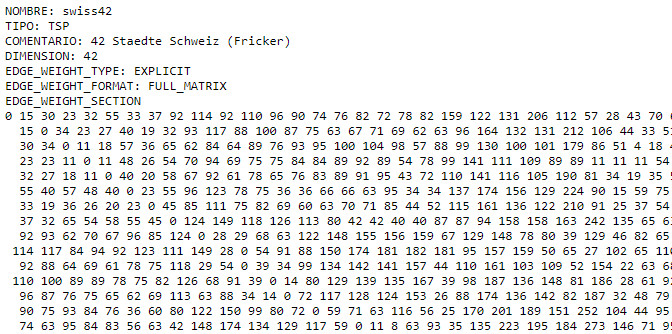

In [9]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(0, 1)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

15

In [10]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional
      
def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo solucion TSP")
    plt.show()

#Funcionas basicas


In [11]:

#Funcionas basicas
###############################################################################

#Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

sol_temporal = crear_solucion(Nodos)

distancia_total(sol_temporal, problem), sol_temporal

(4522,
 [0,
  15,
  1,
  27,
  11,
  30,
  16,
  25,
  7,
  4,
  10,
  5,
  8,
  22,
  13,
  2,
  19,
  6,
  35,
  36,
  14,
  34,
  39,
  21,
  24,
  32,
  12,
  18,
  41,
  29,
  37,
  31,
  40,
  20,
  23,
  17,
  9,
  28,
  26,
  3,
  33,
  38])

#BUSQUEDA ALEATORIA

In [12]:
# Elimina mensajes de Advertencias sobre veriones futuras
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

Mejor solución: [0, 6, 25, 7, 29, 32, 38, 24, 18, 17, 1, 31, 33, 20, 27, 11, 12, 3, 22, 34, 19, 8, 23, 39, 40, 21, 41, 37, 35, 36, 14, 28, 9, 15, 5, 13, 16, 30, 26, 4, 10, 2]
Distancia     : 3661


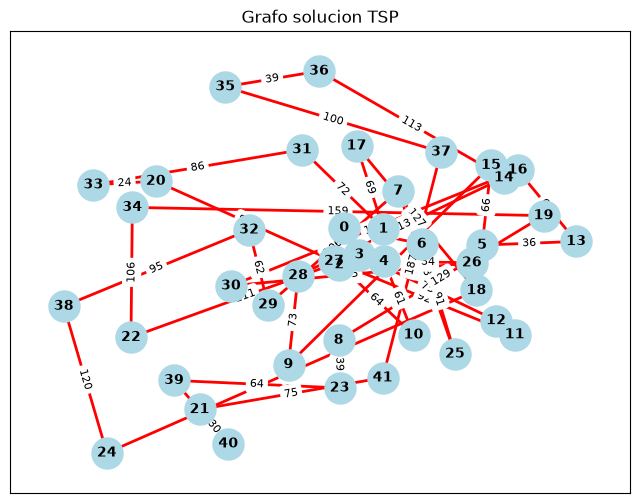

In [13]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  #mejor_distancia = 10e100                         #Inicializamos con un valor alto
  mejor_distancia = float('inf')                    #Inicializamos con un valor alto

  for i in range(N):                                #Criterio de parada: repetir N veces pero podemos incluir otros
    solucion = crear_solucion(Nodos)                #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)  #Calcula el valor objetivo(distancia total)

    if distancia < mejor_distancia:                 #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia


  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion


#Busqueda aleatoria con 10000 iteraciones
solucion = busqueda_aleatoria(problem, 10000)

plot_tsp_solution(problem.edge_weights, solucion)

#BUSQUEDA LOCAL

In [14]:
###############################################################################
# BUSQUEDA LOCAL
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  #Se puede modificar para aplicar otros generadores distintos que 2-opt
  #print(solucion)
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)-1):          #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))


nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3661
Distancia Mejor Solucion Local: 3355


En la iteracion  36 , la mejor solución encontrada es: [0, 15, 16, 14, 19, 13, 5, 6, 1, 32, 38, 34, 33, 20, 35, 36, 37, 10, 41, 25, 11, 12, 18, 26, 7, 17, 31, 23, 40, 24, 21, 39, 22, 2, 4, 3, 27, 28, 30, 29, 9, 8]
Distancia     : 1953


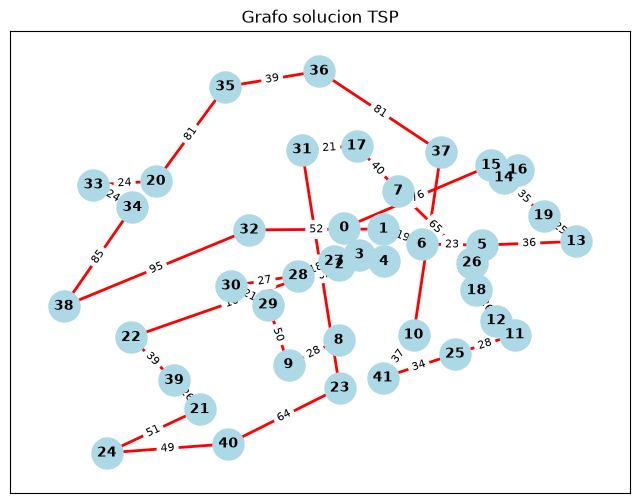

In [15]:
#Busqueda Local:
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.
def busqueda_local(problem):
  mejor_solucion = []

  #Generar una solucion inicial de referencia(aleatoria)
  solucion_referencia = crear_solucion(Nodos)
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador
    #print('#',iteracion)

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
      print("Distancia     :" , mejor_distancia)
      return mejor_solucion

    solucion_referencia = vecina


sol = busqueda_local(problem)

plot_tsp_solution(problem.edge_weights, sol)

#SIMULATED ANNEALING


In [16]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

#Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina.
def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


#Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T,d):
  if random.random() <  math.exp( -1*d / T)  :
    return True
  else:
    return False

#Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.99

La mejor solución encontrada es [0, 30, 38, 29, 28, 6, 26, 5, 18, 12, 11, 25, 41, 23, 8, 10, 4, 2, 3, 9, 40, 24, 21, 39, 22, 34, 33, 20, 32, 27, 1, 31, 35, 36, 15, 16, 14, 19, 13, 7, 37, 17]
con una distancia total de 1827


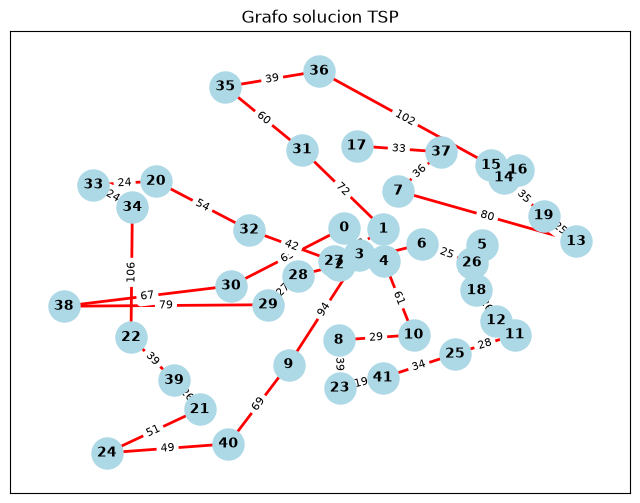

In [17]:
# Recocido Simulado (Simulated Annealing)
def recocido_simulado(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    vecina =genera_vecina_aleatorio(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)
 
    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado(problem, 10000000)

plot_tsp_solution(problem.edge_weights, sol)

# Actividades extra

**Mejora de algoritmo de búsqueda local**

*   Multiarranque
*   Busqueda en entornos variables

**Recocido simulado**

*   Mejora en la selección de vecinos



---
# Mejora de algoritmo de búsqueda local

- Multiarranque
- Busqueda en entornos variables

--- Inia la Búsqueda Local con Multiarranque (5 intentos) ->
Intento 1: Distancia obtenida = 1886
Intento 2: Distancia obtenida = 2159
Intento 3: Distancia obtenida = 2180
Intento 4: Distancia obtenida = 1672
Intento 5: Distancia obtenida = 1827

Mejor distancia global con Multiarranque--->: 1672


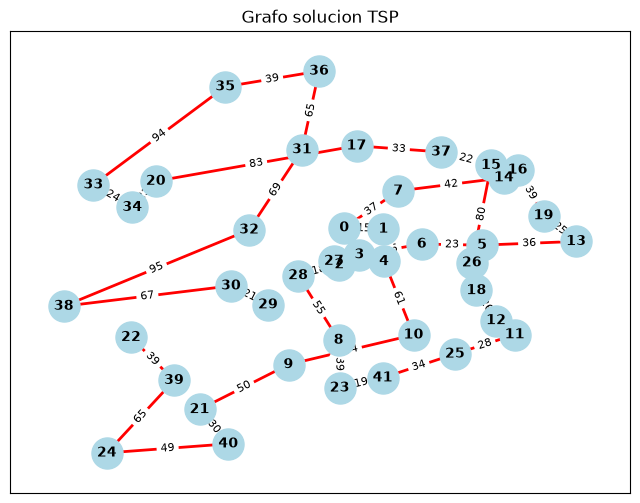


--- Comienza Búsqueda en Entornos Variables (VNS) ---
Iteración 1: Mejora encontrada -> Distancia: 1850
Iteración 6: Mejora encontrada -> Distancia: 1834
Mejor distancia final con VNS: 1834


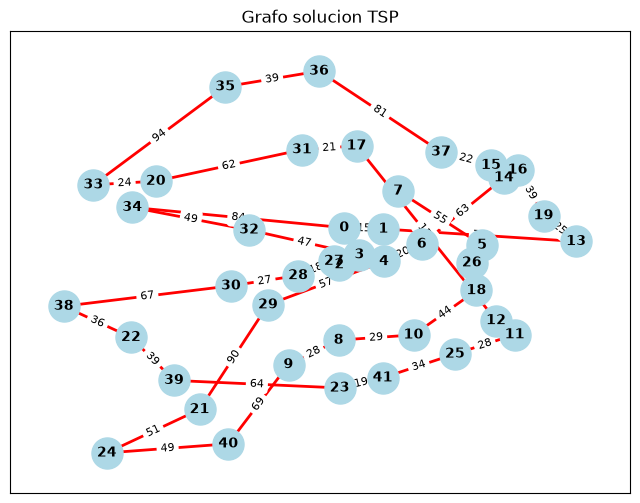

In [18]:


def genera_vecina(solucion):
    # Genera Soluciones vecinas usando 2-opt sistemático
    mejor_solucion = []
    mejor_distancia = 10e100
    for i in range(1, len(solucion)-1):
        for j in range(i+1, len(solucion)):
            vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]
            distancia_vecina = distancia_total(vecina, problem)
            if distancia_vecina <= mejor_distancia:
                mejor_distancia = distancia_vecina
                mejor_solucion = vecina
    return mejor_solucion

def busqueda_local(solucion_inicial, problem):
    # Búsqueda local estándar [basada en el codigo original ]
    actual = solucion_inicial
    distancia_actual = distancia_total(actual, problem)
    
    while True:
        vecina = genera_vecina(actual)
        distancia_vecina = distancia_total(vecina, problem)
        
        if distancia_vecina < distancia_actual:
            actual = vecina
            distancia_actual = distancia_vecina
        else:
            break
    return actual

# ==============================================================================
#  1.- MULTIARRANQUE **Multi-start**
# ==============================================================================
def busqueda_local_multiarranque(problem, num_arranques=10):
    # Ejecuta la búsqueda local múltiples veces desde diferentes puntos de partida aleatorios
    Nodos = list(problem.get_nodes())
    mejor_global = None
    mejor_distancia_global = 10e100
    
    print(f"--- Inia la Búsqueda Local con Multiarranque ({num_arranques} intentos) ->")
    for i in range(num_arranques):
        # Genera solución inicial aleatoria distinta
        sol_inicial = Nodos.copy()
        random.shuffle(sol_inicial)
        
        # Aplicar búsqueda local desde ese punto
        sol_local = busqueda_local(sol_inicial, problem)
        dist_local = distancia_total(sol_local, problem)
        
        # Print
        print(f"Intento {i+1}: Distancia obtenida = {dist_local}")
        
        # Guarda la mejor *global*
        if dist_local < mejor_distancia_global:
            mejor_global = sol_local
            mejor_distancia_global = dist_local
            
    print(f"\nMejor distancia global con Multiarranque--->: {mejor_distancia_global}")
    return mejor_global

# ==============================================================================
# 2.- BÚSQUEDA EN ENTORNOS VARIABLES [***VNS simplificado***]
# ==============================================================================
def perturbacion(solucion, intensidad=3):
    # Modifica aleatoriamente intercambiando varios pares cambiando el entorno
    nueva = solucion.copy()
    n = len(nueva)
    for _ in range(intensidad):
        i, j = random.randint(0, n-1), random.randint(0, n-1)
        nueva[i], nueva[j] = nueva[j], nueva[i]
    return nueva

def busqueda_en_entornos_variables(problem, max_iter=15):
    # Explora distintos entornos cambiando de solución cuando la búsqueda local se estanca.
    Nodos = list(problem.get_nodes())
    actual = Nodos.copy()
    random.shuffle(actual)
    
    mejor_solucion = actual
    mejor_distancia = distancia_total(mejor_solucion, problem)
    
    print(f"\n--- Comienza Búsqueda en Entornos Variables (VNS) ---")
    for iteracion in range(max_iter):
        # 1. Aplicar búsqueda local estándar
        local = busqueda_local(actual, problem)
        dist_local = distancia_total(local, problem)
        
        if dist_local < mejor_distancia:
            mejor_solucion = local
            mejor_distancia = dist_local
            print(f"Iteración {iteracion+1}: Mejora encontrada -> Distancia: {mejor_distancia}")
        
        # 2. Cambio de entorno (Perturbación, escapa del mínimo local)
        intensidad_salto = random.randint(2, 5)
        actual = perturbacion(mejor_solucion, intensidad=intensidad_salto)
        
    print(f"Mejor distancia final con VNS: {mejor_distancia}")
    return mejor_solucion

# Ejecución ---->
# Ejecutar Multiarranque
sol_multi = busqueda_local_multiarranque(problem, num_arranques=5)
plot_tsp_solution(problem.edge_weights, sol_multi)

# Ejecutar Búsqueda en Entornos Variables (VNS)
sol_vns = busqueda_en_entornos_variables(problem, max_iter=10)
plot_tsp_solution(problem.edge_weights, sol_vns)

---
# Recocido simulado Mejorado

  - Mejora en la selección de vecinos

La mejor solución encontrada es:  [26, 0, 1, 7, 32, 2, 27, 28, 30, 29, 8, 25, 10, 41, 23, 9, 40, 21, 24, 39, 22, 38, 34, 33, 20, 31, 35, 36, 17, 37, 14, 15, 16, 5, 19, 13, 11, 12, 18, 4, 3, 6]
Con una distancia total de:  1557


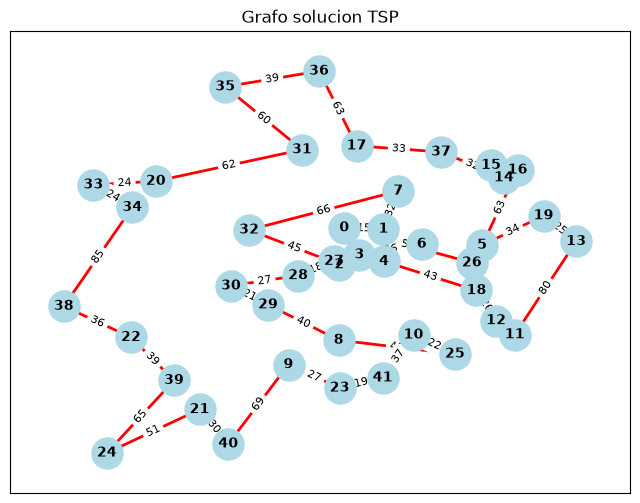

In [20]:


def genera_vecina_2opt(solucion):
    # Genera la solución vecina (invierte un subsegmento aleatorio (Operador 2-opt))
    n = len(solucion)
    i = random.randint(0, n - 1)
    j = random.randint(0, n - 1)
    
    #  i y j deben ser distintos y ordenados
    if i > j:
        i, j = j, i
    if i == j:
        return solucion.copy()
        
    nueva_solucion = solucion.copy()
    # se invierte la sublista entre i y j (operación clásica 2-opt)
    nueva_solucion[i:j+1] = reversed(nueva_solucion[i:j+1])
    return nueva_solucion

def probabilidad(T, delta):
    # Calcula la probabilidad de aceptar una peor solución (Se basada en la temperatura)
    if T <= 0:
        return False
    # Fórmula estándar de Boltzmann (recocido simulado)
    return random.random() < math.exp(-delta / T)

def bajar_temperatura(T):
    # Reduce la temperatura mediante un factor de enfriamiento geométrico
    return T * 0.99

def recocido_simulado(problem, TEMPERATURA):
    # Obtiene la lista de nodos ( desde la fuente del problema de tsplib95
    Nodos = list(problem.get_nodes())
    
    # Solución inicial de referencia (aleatoria)
    solucion_referencia = Nodos.copy()
    random.shuffle(solucion_referencia)
    
    # Usa la función distancia_total ya implementada anteriormente en el notebook
    distancia_referencia = distancia_total(solucion_referencia, problem)

    mejor_solucion = solucion_referencia.copy()
    mejor_distancia = distancia_referencia

    N = 0
    while TEMPERATURA > 0.0001:
        N += 1
        
        # Generar una solución vecina estructurada usando 2-opt
        vecina = genera_vecina_2opt(solucion_referencia)

        # Calcula su valor (distancia) usando la misma función
        distancia_vecina = distancia_total(vecina, problem)
     
        # Si es la mejor solución de todas, se guarda siempre
        if distancia_vecina < mejor_distancia:
            mejor_solucion = vecina.copy()
            mejor_distancia = distancia_vecina

        # Criterio de aceptación: si mejora o pasa la prueba de probabilidad térmica
        delta = abs(distancia_referencia - distancia_vecina)
        if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, delta):
            solucion_referencia = vecina.copy()
            distancia_referencia = distancia_vecina

        # Se baja la temperatura gradualmente
        TEMPERATURA = bajar_temperatura(TEMPERATURA)

    print("La mejor solución encontrada es: ", mejor_solucion)
    print("Con una distancia total de: ", mejor_distancia)
    return mejor_solucion

# Ejecución del algoritmo con una temperatura inicial alta
sol = recocido_simulado(problem, 10000000)

# solución resultante
plot_tsp_solution(problem.edge_weights, sol)